# Import Required Libraries

Import các thư viện cần thiết bao gồm pandas, numpy, catboost, sklearn.metrics, và matplotlib.

In [1]:
import pandas as pd
import numpy as np
import catboost as cb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import optuna

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load and Preprocess Data

Load tập dữ liệu đã xử lý, đảm bảo sắp xếp theo thời gian, xử lý giá trị thiếu trong các biến lag, và chuẩn bị input features và target.

In [2]:
# Load processed data
DATA_PATH = Path('Data') / 'processedData.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['time'])

# Ensure data is sorted by time
df = df.sort_values('time').reset_index(drop=True)

# Define features and target
features = [
    'lat', 'lon', 'abs_lat', 'month_sin', 'month_cos', 'time_index',
    'precip_prev_1m_mean', 'precip_prev_3m_mean', 'precip_prev_12m_mean',
    'precip_monthly_climate', 'quality_flag', 'num_obs_fraction', 'num_obs_rate'
]
target = 'precipitation'

# Handle any remaining missing values in lag features (though they should be filled in preprocessing)
df[features] = df[features].fillna(df[features].median())

# Prepare X and y
X = df[features]
y = df[target]

print(f'Dataset shape: {df.shape}')
print(f'Features: {features}')
print(f'Target: {target}')
print(f'Date range: {df["time"].min()} to {df["time"].max()}')

Dataset shape: (677376, 25)
Features: ['lat', 'lon', 'abs_lat', 'month_sin', 'month_cos', 'time_index', 'precip_prev_1m_mean', 'precip_prev_3m_mean', 'precip_prev_12m_mean', 'precip_monthly_climate', 'quality_flag', 'num_obs_fraction', 'num_obs_rate']
Target: precipitation
Date range: 2005-01-01 00:00:00 to 2020-12-01 00:00:00


# Time-Based Data Split

Chia dữ liệu thành train (2005-2014), validation (2015-2018), và test (2019-2020) mà không shuffle để tránh leakage theo thời gian.

In [3]:
# Time-based split
train_mask = df['year'] <= 2014
val_mask = (df['year'] >= 2015) & (df['year'] <= 2018)
test_mask = df['year'] >= 2019

X_train = X[train_mask]
y_train = y[train_mask]
X_val = X[val_mask]
y_val = y[val_mask]
X_test = X[test_mask]
y_test = y[test_mask]

print(f'Train set: {X_train.shape[0]} samples ({df[train_mask]["year"].min()}-{df[train_mask]["year"].max()})')
print(f'Validation set: {X_val.shape[0]} samples ({df[val_mask]["year"].min()}-{df[val_mask]["year"].max()})')
print(f'Test set: {X_test.shape[0]} samples ({df[test_mask]["year"].min()}-{df[test_mask]["year"].max()})')

Train set: 423360 samples (2005-2014)
Validation set: 169344 samples (2015-2018)
Test set: 84672 samples (2019-2020)


# Configure CatBoost Model

Thiết lập CatBoost Regressor với các siêu tham số được chỉ định: iterations=2000, learning_rate=0.03, depth=6, subsample=0.8, colsample_bylevel=0.8, random_state=42.

In [4]:
# Configure CatBoost model
model = cb.CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    subsample=0.8,
    colsample_bylevel=0.8,
    random_state=42,
    verbose=100  # Show progress every 100 iterations
)

print('Model configuration:')
for param, value in model.get_params().items():
    print(f'{param}: {value}')

Model configuration:
iterations: 2000
learning_rate: 0.03
depth: 6
loss_function: RMSE
verbose: 100
subsample: 0.8
colsample_bylevel: 0.8
random_state: 42


# Optimize Hyperparameters with Optuna

Sử dụng Optuna để tối ưu hóa hyperparameters cho CatBoost Regressor dựa trên validation set.

In [5]:
# Define objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    params = {
        'iterations': trial.suggest_int('iterations', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_state': 42,
        'verbose': 0
    }

    # Create model with suggested params
    model = cb.CatBoostRegressor(**params)

    # Train on train set
    model.fit(X_train, y_train)

    # Predict on validation set
    y_val_pred = model.predict(X_val)

    # Calculate MAE (primary metric)
    mae = mean_absolute_error(y_val, y_val_pred)

    return mae

# Run Optuna study
study = optuna.create_study(direction='minimize')  # Minimize MAE
study.optimize(objective, n_trials=50)  # Adjust n_trials as needed

# Get best parameters
best_params = study.best_params
best_params['random_state'] = 42
best_params['verbose'] = 100

print('Best hyperparameters found:')
for param, value in best_params.items():
    print(f'{param}: {value}')
print(f'Best MAE: {study.best_value:.4f}')

# Update model with best parameters
model = cb.CatBoostRegressor(**best_params)

[I 2026-04-14 01:23:11,218] A new study created in memory with name: no-name-d41583ae-f242-4bef-93b2-b26ce745f4ec
[I 2026-04-14 01:23:48,952] Trial 0 finished with value: 2.490632204228807 and parameters: {'iterations': 878, 'learning_rate': 0.08705322522780316, 'depth': 8, 'subsample': 0.653026445294991, 'colsample_bylevel': 0.9724561445279054, 'l2_leaf_reg': 1.5205340160363154}. Best is trial 0 with value: 2.490632204228807.
[I 2026-04-14 01:24:47,357] Trial 1 finished with value: 2.5455309660097223 and parameters: {'iterations': 1298, 'learning_rate': 0.1555750910288171, 'depth': 5, 'subsample': 0.8899404946286611, 'colsample_bylevel': 0.7237907193356078, 'l2_leaf_reg': 8.772704933715948}. Best is trial 0 with value: 2.490632204228807.
[I 2026-04-14 01:25:21,240] Trial 2 finished with value: 2.100385671763056 and parameters: {'iterations': 1026, 'learning_rate': 0.014556694202818505, 'depth': 4, 'subsample': 0.7417861175775864, 'colsample_bylevel': 0.6647664673680745, 'l2_leaf_reg':

Best hyperparameters found:
iterations: 514
learning_rate: 0.01064381599576595
depth: 7
subsample: 0.7179229811246715
colsample_bylevel: 0.6842803215227844
l2_leaf_reg: 5.947287369171644
random_state: 42
verbose: 100
Best MAE: 2.0895


# Train the Model

Train mô hình CatBoost trên tập train sử dụng tập validation để dừng sớm nếu cần.

In [6]:
# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=100,
    verbose=100
)

print('Model training completed.')

0:	learn: 5.9498788	test: 5.7193049	best: 5.7193049 (0)	total: 45.5ms	remaining: 23.4s
100:	learn: 3.8042992	test: 3.6608777	best: 3.6608777 (100)	total: 4.5s	remaining: 18.4s
200:	learn: 3.3407764	test: 3.2611394	best: 3.2611394 (200)	total: 8.19s	remaining: 12.7s
300:	learn: 3.2128331	test: 3.1910160	best: 3.1910160 (300)	total: 11.4s	remaining: 8.04s
400:	learn: 3.1470048	test: 3.1784285	best: 3.1784285 (400)	total: 14.5s	remaining: 4.07s
500:	learn: 3.0989873	test: 3.1788469	best: 3.1780730 (406)	total: 17.4s	remaining: 451ms
Stopped by overfitting detector  (100 iterations wait)

bestTest = 3.178072957
bestIteration = 406

Shrink model to first 407 iterations.
Model training completed.


# Evaluate on Train, Validation, and Test Sets

Tính toán và báo cáo MAE, RMSE, và R² cho tập train, validation, và test.

In [7]:
# Function to calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{set_name} Metrics:')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²: {r2:.4f}')
    print()
    return mae, rmse, r2

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_mae, train_rmse, train_r2 = calculate_metrics(y_train, y_train_pred, 'Train')
val_mae, val_rmse, val_r2 = calculate_metrics(y_val, y_val_pred, 'Validation')
test_mae, test_rmse, test_r2 = calculate_metrics(y_test, y_test_pred, 'Test')

Train Metrics:
  MAE: 2.0603
  RMSE: 3.1434
  R²: 0.7247

Validation Metrics:
  MAE: 2.1015
  RMSE: 3.1781
  R²: 0.6934

Test Metrics:
  MAE: 2.1076
  RMSE: 3.2028
  R²: 0.6932



# Analyze Errors by Season

Nhóm dự đoán theo tháng hoặc mùa và tính toán các metric lỗi để phân tích hiệu suất theo mùa.

In [8]:
# Analyze errors by season on test set
test_df = df[test_mask].copy()
test_df['y_true'] = y_test
test_df['y_pred'] = y_test_pred
test_df['error'] = test_df['y_true'] - test_df['y_pred']
test_df['abs_error'] = np.abs(test_df['error'])

# Group by season
seasonal_errors = test_df.groupby('season').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': 'count'
}).round(4)

print('Seasonal Error Analysis (Test Set):')
print(seasonal_errors)
print()

# Group by month
monthly_errors = test_df.groupby('month').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': 'count'
}).round(4)

print('Monthly Error Analysis (Test Set):')
print(monthly_errors)

Seasonal Error Analysis (Test Set):
       abs_error   error         y_true
            mean    mean     std  count
season                                 
DJF       2.0476 -0.8997  2.8789  21168
JJA       2.1810 -0.3592  3.1495  21168
MAM       1.5462 -0.0258  2.2928  21168
SON       2.6557 -0.0674  4.0774  21168

Monthly Error Analysis (Test Set):
      abs_error   error         y_true
           mean    mean     std  count
month                                 
1        1.8433 -0.9024  2.5617   7056
2        1.7862 -1.1267  2.3899   7056
3        1.2254  0.0091  1.8523   7056
4        1.2952  0.0382  1.8826   7056
5        2.1180 -0.1247  2.9633   7056
6        1.9876 -0.3140  2.6832   7056
7        2.2951 -1.2071  2.8056   7056
8        2.2603  0.4434  3.6503   7056
9        2.7494 -0.4471  4.1302   7056
10       2.7310  0.5504  4.2453   7056
11       2.4866 -0.3055  3.7704   7056
12       2.5134 -0.6699  3.5338   7056


# Analyze Errors by Geographic Region

Nhóm dự đoán theo bins của lat/lon và tính toán các metric lỗi để phân tích hiệu suất theo vùng địa lý.

In [9]:
# Analyze errors by geographic region on test set
# Create lat/lon bins
test_df['lat_bin'] = pd.cut(test_df['lat'], bins=5, labels=['Very South', 'South', 'Central', 'North', 'Very North'])
test_df['lon_bin'] = pd.cut(test_df['lon'], bins=5, labels=['West', 'Mid-West', 'Central', 'Mid-East', 'East'])

# Group by lat bins
lat_errors = test_df.groupby('lat_bin').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': 'count'
}).round(4)

print('Latitudinal Error Analysis (Test Set):')
print(lat_errors)
print()

# Group by lon bins
lon_errors = test_df.groupby('lon_bin').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': 'count'
}).round(4)

print('Longitudinal Error Analysis (Test Set):')
print(lon_errors)

Latitudinal Error Analysis (Test Set):
           abs_error   error         y_true
                mean    mean     std  count
lat_bin                                    
Very South    2.0532 -0.5230  2.9793  18816
South         2.0739 -0.3308  2.8431  16464
Central       2.2662 -0.4491  3.1594  16464
North         2.2974 -0.3044  3.6804  16464
Very North    1.8552 -0.0565  3.2067  16464

Longitudinal Error Analysis (Test Set):
         abs_error   error         y_true
              mean    mean     std  count
lon_bin                                  
West        2.1483 -0.5028  3.2146  17280
Mid-West    1.7870 -0.2348  2.7014  17280
Central     1.9808 -0.1921  3.1473  15552
Mid-East    2.3469 -0.2824  3.6117  17280
East        2.2624 -0.4635  3.1685  17280


C:\Users\Hello\AppData\Local\Temp\ipykernel_13824\1108317424.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lat_errors = test_df.groupby('lat_bin').agg({
C:\Users\Hello\AppData\Local\Temp\ipykernel_13824\1108317424.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lon_errors = test_df.groupby('lon_bin').agg({


# Analyze Errors by Rainfall Level

Phân loại dự đoán thành các mức không mưa, mưa nhẹ, mưa lớn và tính toán các metric lỗi.

In [10]:
# Analyze errors by rainfall level on test set
# Define rainfall categories based on actual values
def categorize_rainfall(precip):
    if precip == 0:
        return 'No Rain'
    elif precip < 5:
        return 'Light Rain'
    elif precip < 25:
        return 'Moderate Rain'
    else:
        return 'Heavy Rain'

test_df['rain_category'] = test_df['y_true'].apply(categorize_rainfall)

# Group by rainfall category
rainfall_errors = test_df.groupby('rain_category').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': ['count', 'mean']
}).round(4)

print('Rainfall Level Error Analysis (Test Set):')
print(rainfall_errors)

Rainfall Level Error Analysis (Test Set):
              abs_error    error         y_true         
                   mean     mean     std  count     mean
rain_category                                           
Heavy Rain      10.4038  10.3686  7.0194    836  29.4648
Light Rain       1.8097  -1.6182  2.2480  36130   1.8462
Moderate Rain    2.2370   0.4836  3.1151  46150  10.3797
No Rain          0.7332  -0.7332  0.7587   1556   0.0000


# Plot Results and Parameters

Tạo biểu đồ cho các tham số mô hình, dự đoán so với thực tế, và phân phối lỗi sau khi train, validate, và test.

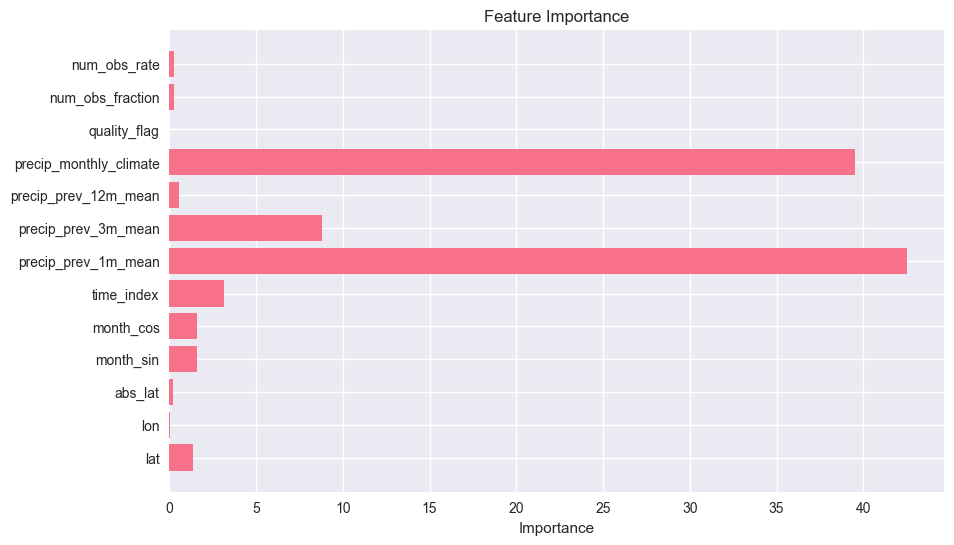

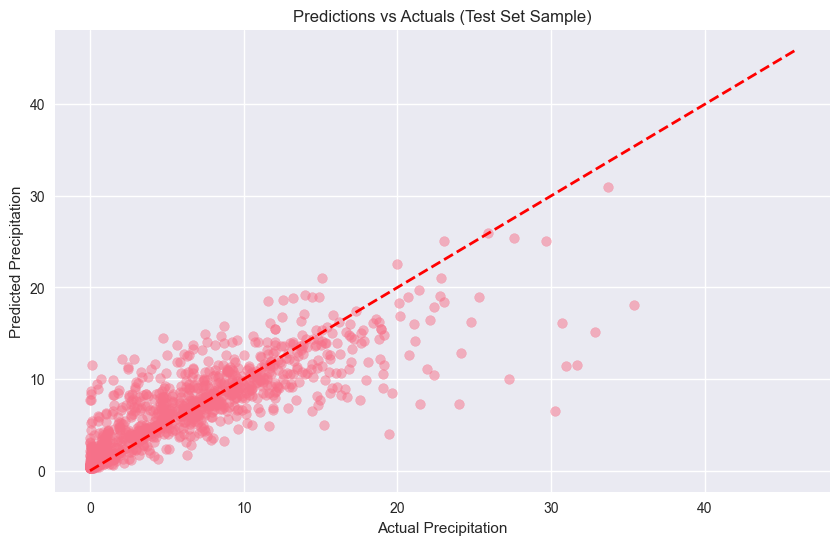

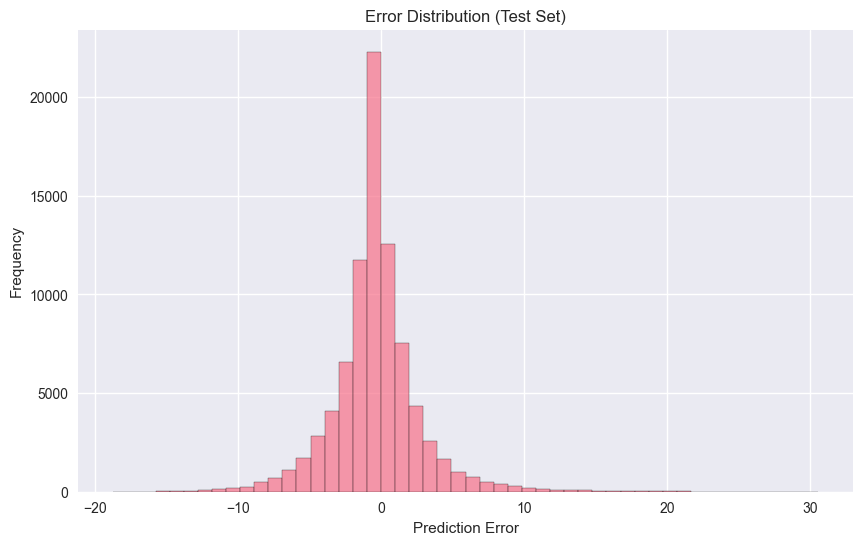

Final Model Parameters:
iterations: 514
learning_rate: 0.01064381599576595
depth: 7
subsample: 0.7179229811246715
colsample_bylevel: 0.6842803215227844


In [11]:
# Plot feature importance
feature_importance = model.get_feature_importance()
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importance)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

# Plot predictions vs actuals for test set (sample)
sample_size = 1000
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

plt.figure(figsize=(10, 6))
plt.scatter(y_test.iloc[sample_indices], y_test_pred[sample_indices], alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Precipitation')
plt.ylabel('Predicted Precipitation')
plt.title('Predictions vs Actuals (Test Set Sample)')
plt.grid(True)
plt.show()

# Plot error distribution
plt.figure(figsize=(10, 6))
plt.hist(test_df['error'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Error Distribution (Test Set)')
plt.grid(True)
plt.show()

# Print final model parameters
print('Final Model Parameters:')
for param in ['iterations', 'learning_rate', 'depth', 'subsample', 'colsample_bylevel']:
    print(f'{param}: {model.get_params()[param]}')